# <font color='orange'>**RapidRelief AI — Sprint 0: Verificación del Entorno**</font>

**Proyecto:** Clasificación Automatizada de Donaciones Textiles  
**Modelo base:** MobileNetV2 (Transferencia de Aprendizaje)  
**Dataset:** Clothing Dataset Small (fotografías reales)  

Este notebook verifica que el entorno de Google Colab está correctamente configurado antes de comenzar el entrenamiento.

## 1. Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Verificar GPU disponible

In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print('TensorFlow version:', tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU disponible: {gpus[0].name}')
else:
    print('ADVERTENCIA: No hay GPU. Ve a Entorno de ejecucion > Cambiar tipo de entorno > GPU T4')

TensorFlow version: 2.19.0
GPU disponible: /physical_device:GPU:0


## 3. Definir rutas del proyecto

In [ ]:
# Rutas base en Google Drive
BASE_DIR    = '/content/drive/MyDrive/RapidReliefAI'

# Clothing Dataset Small
CLOTH_TRAIN = BASE_DIR + '/Datasets/clothing_small/train'
CLOTH_VAL   = BASE_DIR + '/Datasets/clothing_small/validation'
CLOTH_TEST  = BASE_DIR + '/Datasets/clothing_small/test'

# Modelos guardados
MODELS_DIR = BASE_DIR + '/Models'

print('Rutas configuradas:')
print('  Clothing train:', CLOTH_TRAIN)
print('  Clothing val:  ', CLOTH_VAL)
print('  Clothing test: ', CLOTH_TEST)
print('  Modelos:       ', MODELS_DIR)

## 4. Verificar que los directorios y archivos existen

In [ ]:
import os

rutas = [
    ('Clothing train', CLOTH_TRAIN),
    ('Clothing val',   CLOTH_VAL),
    ('Clothing test',  CLOTH_TEST),
    ('Carpeta modelos', MODELS_DIR),
]

todos_ok = True
for nombre, ruta in rutas:
    existe = os.path.exists(ruta)
    estado = 'OK' if existe else 'NO ENCONTRADO'
    print(f'  [{estado}] {nombre}: {ruta}')
    if not existe:
        todos_ok = False

print()
if todos_ok:
    print('Todos los archivos y carpetas encontrados. Listo para continuar.')
else:
    print('CORREGIR las rutas marcadas como NO ENCONTRADO antes de continuar.')

## 5. Conteo de imágenes por clase — Clothing Dataset Small

In [10]:
# Clases esperadas (orden alfabetico, tal como flow_from_directory las asignara)
# 0=dress 1=hat 2=longsleeve 3=outwear 4=pants 5=shirt 6=shoes 7=shorts 8=skirt 9=t-shirt

def contar_imagenes(directorio, nombre_split):
    print(f'\n--- {nombre_split} ---')
    total = 0
    clases = sorted(os.listdir(directorio))
    for clase in clases:
        ruta_clase = os.path.join(directorio, clase)
        if os.path.isdir(ruta_clase):
            n = len([f for f in os.listdir(ruta_clase)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f'  {clase:15s}: {n:4d} imagenes')
            total += n
    print(f'  {"TOTAL":15s}: {total:4d} imagenes')
    return total

n_train = contar_imagenes(CLOTH_TRAIN, 'Clothing Small — Train')
n_val   = contar_imagenes(CLOTH_VAL,   'Clothing Small — Validation')
n_test  = contar_imagenes(CLOTH_TEST,  'Clothing Small — Test')


--- Clothing Small — Train ---
  dress          :  241 imagenes
  hat            :  123 imagenes
  longsleeve     :  455 imagenes
  outwear        :  184 imagenes
  pants          :  468 imagenes
  shirt          :  290 imagenes
  shoes          :  198 imagenes
  shorts         :  202 imagenes
  skirt          :  112 imagenes
  t-shirt        :  795 imagenes
  TOTAL          : 3068 imagenes

--- Clothing Small — Validation ---
  dress          :   32 imagenes
  hat            :   14 imagenes
  longsleeve     :   49 imagenes
  outwear        :   24 imagenes
  pants          :   49 imagenes
  shirt          :   29 imagenes
  shoes          :   26 imagenes
  shorts         :   25 imagenes
  skirt          :   12 imagenes
  t-shirt        :   81 imagenes
  TOTAL          :  341 imagenes

--- Clothing Small — Test ---
  dress          :   15 imagenes
  hat            :   12 imagenes
  longsleeve     :   72 imagenes
  outwear        :   38 imagenes
  pants          :   42 imagenes
  shirt  

## 6. Verificar importación del modelo base (MobileNetV2)

In [13]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Carga rapida solo para verificar — no usaremos este modelo todavia
IMAGE_SIZE = (224, 224)
test_model = MobileNetV2(input_shape=IMAGE_SIZE + (3,), include_top=False, weights='imagenet')
test_model.trainable = False

print('MobileNetV2 cargado correctamente')
print(f'  Input shape:  {test_model.input.shape}')
print(f'  Output shape: {test_model.output.shape}')
print(f'  Capas totales: {len(test_model.layers)}')
print(f'  Parametros: {test_model.count_params():,}')

del test_model  # liberar memoria

9406464/9406464 [==============================] - 2s 0us/step
MobileNetV2 cargado correctamente
  Input shape:  (None, 224, 224, 3)
  Output shape: (None, 7, 7, 1280)
  Capas totales: 154
  Parametros: 2,257,984


## 7. Visualizar muestras del Clothing Dataset

Una muestra por clase (Clothing Small):


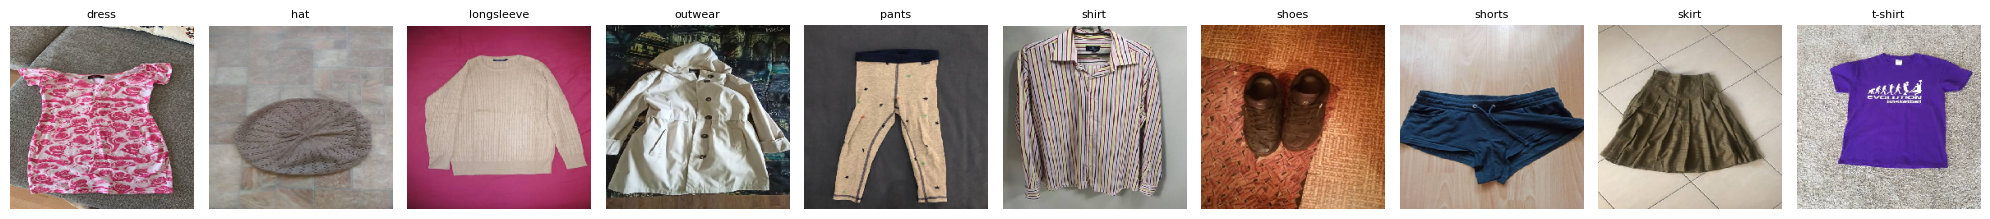

In [14]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def plotImages(images_arr, titulos=None):
    n = len(images_arr)
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 3))
    if n == 1:
        axes = [axes]
    for i, (img, ax) in enumerate(zip(images_arr, axes)):
        ax.imshow(img.astype('uint8'))
        ax.axis('off')
        if titulos:
            ax.set_title(titulos[i], fontsize=8)
    plt.tight_layout()
    plt.show()

# Mostrar una imagen de cada clase del train
clases = sorted(os.listdir(CLOTH_TRAIN))
imagenes = []
titulos = []

for clase in clases:
    ruta_clase = os.path.join(CLOTH_TRAIN, clase)
    archivos = [f for f in os.listdir(ruta_clase)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if archivos:
        ruta_img = os.path.join(ruta_clase, archivos[0])
        img = load_img(ruta_img, target_size=(224, 224))
        imagenes.append(img_to_array(img))
        titulos.append(clase)

print('Una muestra por clase (Clothing Small):')
plotImages(imagenes, titulos)
# Etiquetas: 0=dress 1=hat 2=longsleeve 3=outwear 4=pants 5=shirt 6=shoes 7=shorts 8=skirt 9=t-shirt

## 8. Resumen del entorno

Si todas las celdas anteriores ejecutaron sin error, el entorno está listo.  
Continuar con `01_eda_preprocesamiento.ipynb`.

In [ ]:
print('=== RESUMEN DEL ENTORNO ===')
print(f'TensorFlow:       {tf.__version__}')
print(f'GPU:              {"Si" if tf.config.list_physical_devices("GPU") else "No"}')
print(f'Clothing train:   {n_train} imagenes')
print(f'Clothing val:     {n_val} imagenes')
print(f'Clothing test:    {n_test} imagenes')
print(f'Clases:           10 (dress, hat, longsleeve, outwear, pants, shirt, shoes, shorts, skirt, t-shirt)')
print('Entorno verificado. Listo para Sprint 1.')